<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Project_Test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import kagglehub
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kagglehub import KaggleDatasetAdapter

# Download dataset
dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
images_dir = os.path.join(dataset_path, "images", "images")

# Load artists.csv into a DataFrame
file_path = "artists.csv"
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ikarus777/best-artworks-of-all-time",
  file_path,
)

# Map the dataframe to the folder names
# The folder names use underscores instead of spaces
df['folder_name'] = df['name'].str.replace(' ', '_')

# Verify which artists have valid image folders
df['path_exists'] = df['folder_name'].apply(lambda x: os.path.exists(os.path.join(images_dir, x)))
valid_artists = df[df['path_exists'] == True].copy()

print(f"Successfully mapped {len(valid_artists)} artists.")

100%|██████████| 2.29G/2.29G [02:42<00:00, 15.1MB/s]

Extracting files...


Download already complete (40305 bytes).
Successfully mapped 49 artists.


In [2]:
def extract_artist_features(artist_folder, num_samples=5, k_clusters=5):
    path = os.path.join(images_dir, artist_folder)
    files = [f for f in os.listdir(path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    selected_files = files[:num_samples]

    pixel_data = []
    for f in selected_files:
        img = cv2.imread(os.path.join(path, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        pixel_data.append(img.reshape(-1, 3))

    # Combine pixels from multiple paintings to get a "Style Average"
    combined_pixels = np.vstack(pixel_data)
    kmeans = KMeans(n_clusters=k_clusters, n_init=10)
    kmeans.fit(combined_pixels)

    return kmeans.cluster_centers_.astype(int)

# Dictionary to store the palettes
all_artist_palettes = {}

print("Extracting palettes for all artists... this may take a minute.")
for folder in valid_artists['folder_name']:
    try:
        all_artist_palettes[folder] = extract_artist_features(folder)
    except Exception as e:
        print(f"Skipping {folder} due to error: {e}")

Extracting palettes for all artists... this may take a minute.


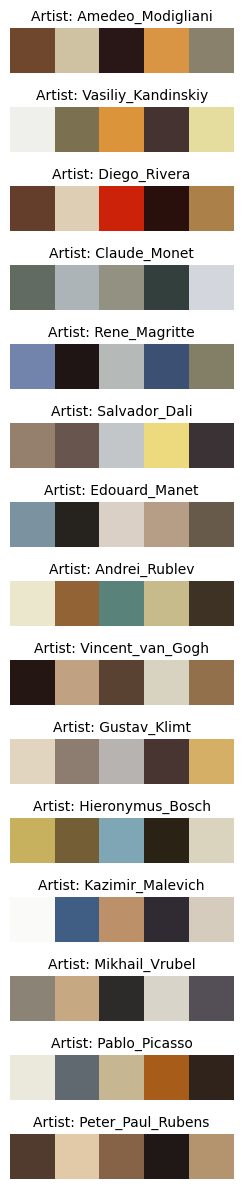

In [3]:
def plot_multi_artist_palettes(palette_dict, limit=10):
    fig, axes = plt.subplots(limit, 1, figsize=(10, limit * 0.8))
    for i, (name, colors) in enumerate(list(palette_dict.items())[:limit]):
        axes[i].imshow([colors.reshape(5, 3).astype(np.uint8)])
        axes[i].set_title(f"Artist: {name}", fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

plot_multi_artist_palettes(all_artist_palettes, limit=15)

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, applications
from tensorflow.keras.applications.resnet50 import preprocess_input

# 替换你之前的 train_datagen 定义
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # 核心修改：使用 ResNet 专用预处理
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

# 确保 target_size 严格为 (224, 224)
train_generator = train_datagen.flow_from_directory(
    images_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Transfer Learning Model (ResNet50)
base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Ready for Training. Model is set to identify 50 different artistic styles.")

Found 7042 images belonging to 51 classes.
Ready for Training. Model is set to identify 50 different artistic styles.


In [14]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(weights))


from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.2, patience=3, min_lr=0.00001)

train_steps = train_generator.samples // train_generator.batch_size

print(f"Total training images: {train_generator.samples}")
print(f"Calculated steps per epoch: {train_steps}")


history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[reduce_lr],
    verbose=1
)

Total training images: 7042
Calculated steps per epoch: 220
Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 126s 574ms/step - accuracy: 0.5375 - loss: 1.3933 - learning_rate: 2.0000e-05
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 67us/step - accuracy: 0.5312 - loss: 1.3758 - learning_rate: 2.0000e-05
Epoch 3/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


220/220 ━━━━━━━━━━━━━━━━━━━━ 127s 576ms/step - accuracy: 0.5481 - loss: 1.3299 - learning_rate: 2.0000e-05
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 62us/step - accuracy: 0.4688 - loss: 1.6915 - learning_rate: 2.0000e-05
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 127s 577ms/step - accuracy: 0.5501 - loss: 1.3319 - learning_rate: 2.0000e-05
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 62us/step - accuracy: 0.5938 - loss: 0.8873 - learning_rate: 2.0000e-05
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 126s 571ms/step - accuracy: 0.5465 - loss: 1.3239 - learning_rate: 2.0000e-05
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 62us/step - accuracy: 0.4375 - loss: 1.5432 - learning_rate: 2.0000e-05
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 125s 570ms/step - accuracy: 0.5609 - loss: 1.2887 - learning_rate: 2.0000e-05
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 76us/step - accuracy: 0.5938 - loss: 1.2878 - learning_rate: 1.0000e-05
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 131s 593ms/step - accuracy: 0.5541 - 

Using Colab cache for faster access to the 'best-artworks-of-all-time' dataset.
Found 8774 images belonging to 51 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


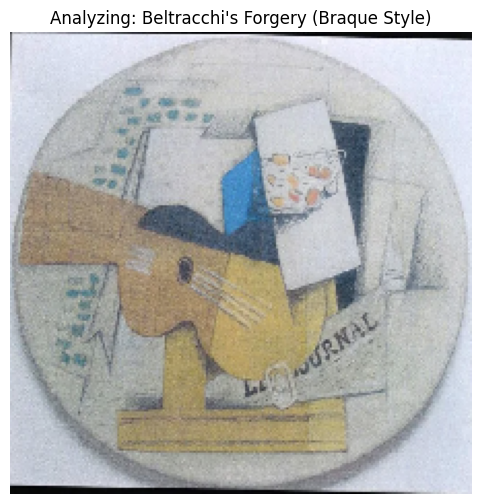

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

        ART FORGERY DETECTION REPORT        
Artist: Jackson_Pollock           | Confidence:  13.30%
Artist: Kazimir_Malevich          | Confidence:   7.10%
Artist: Raphael                   | Confidence:   4.80%
Artist: Gustave_Courbet           | Confidence:   4.31%
Artist: Diego_Velazquez           | Confidence:   3.80%
Conclusion: Style mismatch. AI identifies this as closer to Jackson_Pollock.


In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# --- BEGIN FIX FOR NameError: name 'train_generator' is not defined ---
# These imports and definitions are duplicated from previous cells to ensure
# 'train_generator' and its dependencies are available if the kernel state was lost.
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import tensorflow as tf # Added for model definition
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, applications # Added for model definition
from tensorflow.keras.applications.resnet50 import preprocess_input # Ensure preprocess_input is available

# Re-establish images_dir (from PN26pXpoLz8D)
dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
images_dir = os.path.join(dataset_path, "images", "images")

# Re-establish train_generator with minimal settings to get class_indices (from CXb325VtMr4u)
# The original train_datagen had more arguments, but they are not strictly needed for class_indices.
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    images_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical', # Fixed typo: 'class_class_mode' to 'class_mode'
    subset='training'
)
# --- END FIX ---

# --- BEGIN FIX FOR NameError: name 'model' is not defined ---
# Re-establish model definition and compilation
base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


labels_inv = {v: k for k, v in train_generator.class_indices.items()}

def final_appraisal(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Analyzing: Beltracchi's Forgery (Braque Style)")
    plt.axis('off')
    plt.show()


    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)


    preds = model.predict(x)[0]
    top_indices = np.argsort(preds)[-5:][::-1]

    print("\n" + "="*40)
    print("        ART FORGERY DETECTION REPORT        ")
    print("="*40)
    for i in top_indices:
        name = labels_inv[i]
        score = preds[i] * 100
        print(f"Artist: {name:<25} | Confidence: {score:>6.2f}%")
    print("="*40)

    top_artist = labels_inv[top_indices[0]]
    if "Braque" in top_artist and preds[top_indices[0]] > 0.8:
        print("Conclusion: High match with Braque. Forgery is mathematically convincing.")
    elif "Braque" in top_artist:
        print("Conclusion: Matches Braque style but with LOW confidence. Possible stylistic anomaly.")
    else:
        print(f"Conclusion: Style mismatch. AI identifies this as closer to {top_artist}.")

final_appraisal('test.png')